In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [13]:
class LogisticRegressionAnalyzer:
  def __init__(self, dataset):
    self.dataset = dataset
    self.model = LogisticRegression()
  def prepare_data(self):
    self.X = self.dataset[["Hours_Studied"]]
    self.y = self.dataset["Result"]
  def split_dataset(self):
    self.X_train, self.X_test, \
    self.y_train, self.y_test = train_test_split(
        self.X,
        self.y,
        test_size=0.2,
        random_state=42
    )
  def train_model(self):
    self.model.fit(
        self.X_train,
        self.y_train
    )
  def evaluate_model(self):
    self.predictions = self.model.predict(
        self.X_test
    )
    accuracy = accuracy_score(
        self.y_test,
        self.predictions
    )
    print("\nMODEL EVALUATION")
    print("-" * 40)
    print(
        f"Accuracy : {accuracy:.2f}"
    )
    print("\nConfusion Matrix")
    print(
        confusion_matrix(
            self.y_test,
            self.predictions
        )
    )
  def predict_student(self, hours):
    sample = pd.DataFrame({
        "Hours_Studied": [hours]
    })
    probability = self.model.predict_proba(
        sample
    )[0][1]
    prediction = self.model.predict(
        sample
    )[0]
    result = 'Pass' if prediction == 1 else 'Fail'
    print("\nPREDICTION")
    print('-' * 40)
    print(f"Study Hours : {hours}")
    print(f"Probability of Passing : {probability:.2f}")
    print(f"Predicted Result : {result}")
  def visualize(self):
    plt.figure(figsize=(8, 5))
    plt.scatter(
        self.dataset['Hours_Studied'],
        self.dataset['Result']
    )
    plt.xlabel("Hours Studied")
    plt.ylabel("Result (0=Fail, 1=Pass)")
    plt.title("Logistic Regression Dataset")
    plt.grid(True)
    plt.show()

In [14]:
# ----------------------
# Dataset
# ----------------------
data = pd.DataFrame({
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Result": [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
})


MODEL EVALUATION
----------------------------------------
Accuracy : 1.00

Confusion Matrix
[[1 0]
 [0 1]]

PREDICTION
----------------------------------------
Study Hours : 7
Probability of Passing : 0.95
Predicted Result : Pass


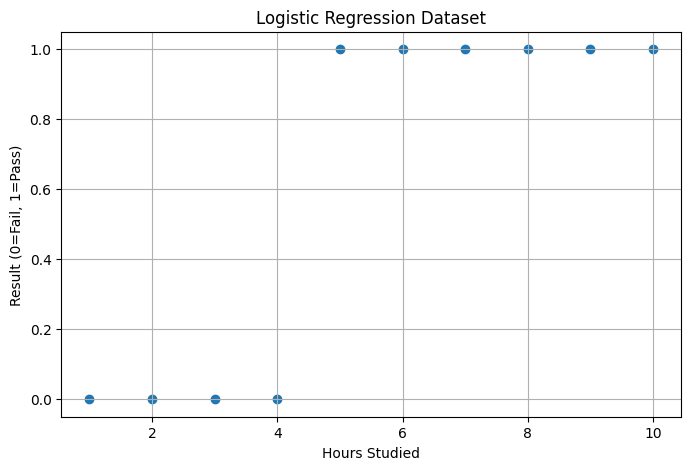

In [15]:
# ----------------------
# Workflow
# ----------------------
analysis = LogisticRegressionAnalyzer(data)
analysis.prepare_data()
analysis.split_dataset()
analysis.train_model()
analysis.evaluate_model()
analysis.predict_student(7)
analysis.visualize()